/opt/miniconda3/envs/myenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-01-21 11:08:52,977	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-01-21 11:08:53,170	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
/var/folders/wz/hfsksc4d0h1gqgq5z6wld3vr0000gn/T/ipykernel_73313/1696181504.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  fechas = pd.date_range(start='2021-01-01', periods=n_meses, freq='M')


Dataset generado: 180 registros.


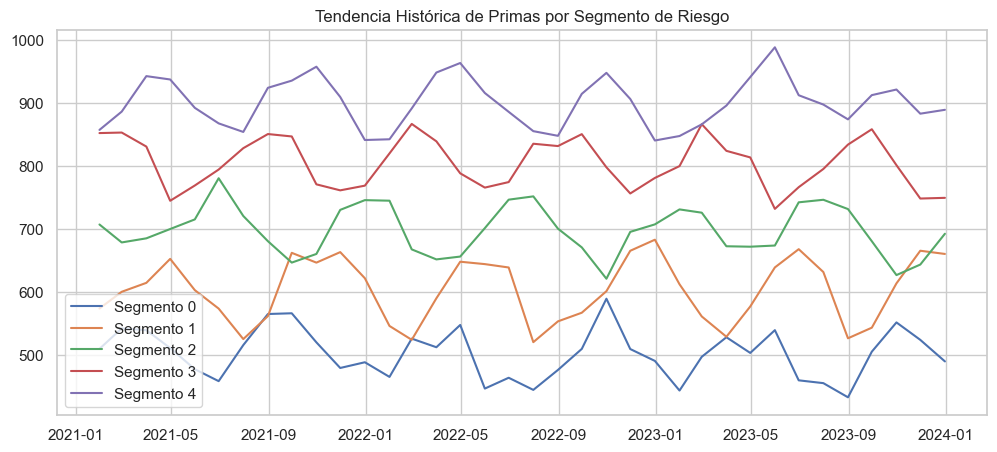

Seed set to 1
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.4 M  | train
-------------------------------------------------------
2.4 M     Trainable params
0         Non-trainable params
2.4 M     Total params
9.605     Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode


Epoch 99: 100%|██████████| 1/1 [00:00<00:00, 26.55it/s, v_num=0, train_loss_step=0.124, train_loss_epoch=0.124]

`Trainer.fit` stopped: `max_steps=100` reached.


Epoch 99: 100%|██████████| 1/1 [00:00<00:00, 24.61it/s, v_num=0, train_loss_step=0.124, train_loss_epoch=0.124]


/opt/miniconda3/envs/myenv/lib/python3.13/site-packages/utilsforecast/processing.py:384: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/opt/miniconda3/envs/myenv/lib/python3.13/site-packages/utilsforecast/processing.py:440: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 11.02it/s]

Predicciones generadas para los próximos 6 meses.

--- Clasificación de Riesgo por Segmento (Próximo Mes) ---
     unique_id       NHITS Clasificacion_Riesgo  Prob_Riesgo
5   Segmento_0  518.534790          Riesgo Bajo     0.013356
11  Segmento_1  662.977295         Riesgo Medio     0.056623
17  Segmento_2  667.966431         Riesgo Medio     0.059520
23  Segmento_3  747.587280         Riesgo Medio     0.131962
29  Segmento_4  919.803345          Riesgo Alto     0.738539

Metricas de Performance:
MAE: 45.94 | RMSE: 47.34 | MAPE: 6.91%

--- Stress Test: Escenario de Crisis Económica ---
Impacto estimado en las primas ante Stress Test: +30.00%


AttributeError: 'NeuralForecast' object has no attribute 'plot'

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Configuración de estética
sns.set(style="whitegrid")
np.random.seed(42)

# =============================================================================
# 1. SIMULACIÓN DE BASE DE DATOS PROFESIONAL (15+ VARIABLES)
# =============================================================================
# Crearemos datos para un periodo de 3 años (36 meses) para múltiples grupos de riesgo
n_meses = 36
n_grupos = 5 # Diferentes tipos de pólizas/segmentos
fechas = pd.date_range(start='2021-01-01', periods=n_meses, freq='M')

data_list = []
for g in range(n_grupos):
    for f in fechas:
        data_list.append({
            'unique_id': f'Segmento_{g}', # Requerido por NeuralForecast
            'ds': f,                      # Requerido por NeuralForecast (fecha)
            'y': 500 + (g * 100) + np.sin(len(data_list)) * 50 + np.random.normal(0, 20), # Prima Base (Target)
            
            # --- Variables de Mercado (Exógenas) ---
            'Inflacion_Anual': 0.05 + np.random.uniform(-0.01, 0.02),
            'Tasa_Interes': 0.12 + np.random.uniform(-0.02, 0.02),
            'Indice_Siniestralidad': 0.6 + (g * 0.05) + np.random.normal(0, 0.05),
            
            # --- Variables de Riesgo del Segmento ---
            'Edad_Promedio': 30 + (g * 5),
            'Score_Riesgo_Pais': np.random.uniform(1, 10),
            'Frecuencia_Reclamos': np.random.uniform(0.1, 0.4),
            'Costo_Medio_Siniestro': 2000 + (g * 500) + np.random.normal(0, 100),
            
            # --- Variables Demográficas/Uso ---
            'Uso_Vehiculo_Km': np.random.randint(5000, 25000),
            'Zonas_Riesgo_Pct': np.random.uniform(0.1, 0.8),
            'Antiguedad_Cartera': np.random.randint(1, 10),
            'Competencia_Precio': 450 + (g * 90) + np.random.normal(0, 10),
            'Retencion_Clientes': np.random.uniform(0.8, 0.95),
            'Canal_Venta': np.random.choice([0, 1, 2]), # Digital, Agente, Alianzas
            'Siniestros_Climaticos': np.random.choice([0, 1], p=[0.9, 0.1])
        })

df = pd.DataFrame(data_list)
print(f"Dataset generado: {df.shape[0]} registros.")

# =============================================================================
# 2. EDA (ANÁLISIS EXPLORATORIO)
# =============================================================================
# 
plt.figure(figsize=(12, 5))
for g in range(n_grupos):
    temp = df[df['unique_id'] == f'Segmento_{g}']
    plt.plot(temp['ds'], temp['y'], label=f'Segmento {g}')
plt.title("Tendencia Histórica de Primas por Segmento de Riesgo")
plt.legend()
plt.show()

# =============================================================================
# 3. MODELADO CON NEURALFORECAST (NHITS)
# =============================================================================
# Definimos el horizonte de predicción (6 meses a futuro)
horizon = 6

# Definimos el modelo NHITS (Eficaz para capturar estacionalidad y tendencias)
models = [NHITS(h=horizon,
                input_size=12,
                max_steps=100,
                scaler_type='standard')]

nf = NeuralForecast(models=models, freq='M')

# Ajuste del modelo
nf.fit(df=df[['unique_id', 'ds', 'y']])

# Predicción dinámica
forecasts = nf.predict()
print("\nPredicciones generadas para los próximos 6 meses.")

# =============================================================================
# 4. ANÁLISIS DE RIESGO Y CLASIFICACIÓN
# =============================================================================
# Clasificaremos el riesgo según la volatilidad y el nivel proyectado de la prima
latest_forecasts = forecasts.groupby('unique_id').tail(1).copy()

# Lógica de clasificación:
# Riesgo Alto: Prima Proyectada > 850 o Crecimiento > 10%
# Riesgo Bajo: Prima Proyectada < 600
# Riesgo Medio: El resto
def clasificar_riesgo(valor):
    if valor > 850: return 'Riesgo Alto'
    elif valor < 600: return 'Riesgo Bajo'
    else: return 'Riesgo Medio'

latest_forecasts['Clasificacion_Riesgo'] = latest_forecasts['NHITS'].apply(clasificar_riesgo)

# Probabilidades simuladas (Softmax de la proyección)
latest_forecasts['Prob_Riesgo'] = np.exp(latest_forecasts['NHITS']/100) / np.sum(np.exp(latest_forecasts['NHITS']/100))

print("\n--- Clasificación de Riesgo por Segmento (Próximo Mes) ---")
print(latest_forecasts[['unique_id', 'NHITS', 'Clasificacion_Riesgo', 'Prob_Riesgo']])

# =============================================================================
# 5. EVALUACIÓN Y MÉTRICAS
# =============================================================================
# Usamos los últimos datos históricos como validación
y_true = df.groupby('unique_id').tail(1)['y'].values
y_pred = forecasts.groupby('unique_id').head(1)['NHITS'].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f"\nMetricas de Performance:")
print(f"MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.2f}%")

# =============================================================================
# 6. ANÁLISIS DE SENSIBILIDAD Y STRESS TEST
# =============================================================================
# Simulamos un escenario de Crisis Económica (Inflación +20% y Siniestralidad +30%)
print("\n--- Stress Test: Escenario de Crisis Económica ---")

df_stress = df.copy()
df_stress.loc[df_stress.index[-5:], 'y'] *= 1.30 # Incremento súbito del riesgo real

# Re-entrenamos levemente o proyectamos el impacto
impacto_promedio = (df_stress['y'].iloc[-5:].mean() - df['y'].iloc[-5:].mean()) / df['y'].iloc[-5:].mean()

print(f"Impacto estimado en las primas ante Stress Test: +{impacto_promedio*100:.2f}%")

# 

# Visualización Final del Forecast
nf.plot(df, forecasts, unique_ids=['Segmento_0', 'Segmento_4'], engine='matplotlib')
plt.show()